# DDoS Attack Detection — FAMS Feature Selection Framework

**Datasets:** CIC-IDS 2018 (`02-16-2018.csv`, `02-21-2018.csv`) + CIC-DDoS 2019  
**Models:** K-Nearest Neighbours (KNN) · Random Forest (RF) · XGBoost  
**Feature Selection:** FAMS — 5-method ensemble vote ≥ 4/5 → 21 features

### FAMS Framework (Ma et al., 2023)
| Phase | Description |
|---|---|
| 1. Data Preparation | Feature coding, inf/NaN removal, duplicate removal, balancing, normalisation |
| 2. Feature Selection | 5 methods (Variance, MI, Backward Elim., Lasso L1, RF Importance) — keep features selected by > 3 methods |
| 3. Model Selection | Compare classifiers via Accuracy, Precision, Recall, F1, Average |
| 4. Optimisation | Tune best model hyperparameters |

**Paper's 21 selected features (Table 3):**  
Destination Port, Fwd Packet Length Mean, Flow IAT Max, Subflow Bwd Bytes, Init_Win_bytes_backward, Protocol, Total Length of Bwd Packets, Fwd Packet Length Max, Fwd Packet Length Std, Flow Bytes/s, Fwd IAT Max, Fwd Header Length, Bwd Header Length, Max Packet Length, Packet Length Mean, Packet Length Variance, ACK Flag Count, Average Packet Size, Avg Fwd Segment Size, Init_Win_bytes_forward, min_seg_size_forward

In [1]:
# Install required packages (run once)
# !pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn tqdm

In [2]:
import os
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
print('All imports successful.')


All imports successful.


## Pipeline Overview

| Phase | Dataset | Purpose |
|---|---|---|
| **1. FAMS Feature Selection** | CIC-IDS 2018 | Select features via 5-method ensemble vote ≥ 4/5 |
| **2. Model Training & Evaluation** | CIC-DDoS 2019 | Train KNN / RF / XGBoost on selected features |
| **Hyperparameter Optimisation** | CIC-DDoS 2019 | Optuna TPE sampler — 30 trials per model |

**Download datasets:**
```
kaggle datasets download solarmainframe/ids-intrusion-csv   # IDS 2018 → data/ids2018/
kaggle datasets download dhoogla/cicddos2019               # DDoS 2019 → data/ddos2019/
```

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

# Phase 1: CIC-IDS 2018 files used for FAMS feature selection
CIC_IDS2018_FILES = [
    'data/ids2018/02-16-2018.csv',
    'data/ids2018/02-21-2018.csv',
]

# Phase 2: CIC-DDoS 2019 directory (Parquet files) used for training/testing
CIC_DDOS2019_DIR = 'data/ddos2019/'

# Rows sampled per file (None = all rows)
SAMPLE_PER_FILE     = 100_000   # IDS2018
SAMPLE_DDOS_PER_FILE = None     # DDoS2019 — use all rows for training

APPLY_SMOTE      = True
TOP_N_PER_METHOD = 25
VOTE_THRESHOLD   = 3     # >= 4 of 5 methods
OPTUNA_TRIALS    = 30    # trials per model
OPTUNA_SUBSAMPLE = 50_000  # rows used inside each Optuna trial (speed)

SEED = 42

# ── CIC-IDS 2018 column rename (abbreviated → canonical) ────────────────────
IDS2018_RENAME = {
    'Dst Port':        'Destination Port',
    'Tot Fwd Pkts':    'Total Fwd Packets',
    'Tot Bwd Pkts':    'Total Backward Packets',
    'TotLen Fwd Pkts': 'Fwd Packets Length Total',
    'TotLen Bwd Pkts': 'Bwd Packets Length Total',
    'Fwd Pkt Len Max': 'Fwd Packet Length Max',
    'Fwd Pkt Len Min': 'Fwd Packet Length Min',
    'Fwd Pkt Len Mean':'Fwd Packet Length Mean',
    'Fwd Pkt Len Std': 'Fwd Packet Length Std',
    'Bwd Pkt Len Max': 'Bwd Packet Length Max',
    'Bwd Pkt Len Min': 'Bwd Packet Length Min',
    'Bwd Pkt Len Mean':'Bwd Packet Length Mean',
    'Bwd Pkt Len Std': 'Bwd Packet Length Std',
    'Flow Byts/s':     'Flow Bytes/s',
    'Flow Pkts/s':     'Flow Packets/s',
    'Fwd IAT Tot':     'Fwd IAT Total',
    'Bwd IAT Tot':     'Bwd IAT Total',
    'Fwd Header Len':  'Fwd Header Length',
    'Bwd Header Len':  'Bwd Header Length',
    'Fwd Pkts/s':      'Fwd Packets/s',
    'Bwd Pkts/s':      'Bwd Packets/s',
    'Pkt Len Min':     'Packet Length Min',
    'Pkt Len Max':     'Packet Length Max',
    'Pkt Len Mean':    'Packet Length Mean',
    'Pkt Len Std':     'Packet Length Std',
    'Pkt Len Var':     'Packet Length Variance',
    'FIN Flag Cnt':    'FIN Flag Count',
    'SYN Flag Cnt':    'SYN Flag Count',
    'RST Flag Cnt':    'RST Flag Count',
    'PSH Flag Cnt':    'PSH Flag Count',
    'ACK Flag Cnt':    'ACK Flag Count',
    'URG Flag Cnt':    'URG Flag Count',
    'ECE Flag Cnt':    'ECE Flag Count',
    'Pkt Size Avg':    'Avg Packet Size',
    'Fwd Seg Size Avg':'Avg Fwd Segment Size',
    'Bwd Seg Size Avg':'Avg Bwd Segment Size',
    'Fwd Byts/b Avg':  'Fwd Avg Bytes/Bulk',
    'Fwd Pkts/b Avg':  'Fwd Avg Packets/Bulk',
    'Fwd Blk Rate Avg':'Fwd Avg Bulk Rate',
    'Bwd Byts/b Avg':  'Bwd Avg Bytes/Bulk',
    'Bwd Pkts/b Avg':  'Bwd Avg Packets/Bulk',
    'Bwd Blk Rate Avg':'Bwd Avg Bulk Rate',
    'Subflow Fwd Pkts':'Subflow Fwd Packets',
    'Subflow Fwd Byts':'Subflow Fwd Bytes',
    'Subflow Bwd Pkts':'Subflow Bwd Packets',
    'Subflow Bwd Byts':'Subflow Bwd Bytes',
    'Init Fwd Win Byts':'Init Fwd Win Bytes',
    'Init Bwd Win Byts':'Init Bwd Win Bytes',
    'Fwd Act Data Pkts':'Fwd Act Data Packets',
}

# ── CIC-DDoS 2019 label normalisation ───────────────────────────────────────
# Remove "DrDoS_" prefix; normalise "UDP-lag" → "UDPLag"
def normalise_ddos_label(lbl: str) -> str:
    lbl = str(lbl).strip()
    if lbl.startswith('DrDoS_'):
        lbl = lbl[len('DrDoS_'):]
    if lbl == 'UDP-lag':
        lbl = 'UDPLag'
    return lbl

print('Configuration loaded.')


Configuration loaded.


In [4]:
def load_csv_files(file_paths, sample_size=None, label_col='Label',
                   keep_labels=None, source_tag=None, rename_map=None):
    frames = []
    for fpath in file_paths:
        if not os.path.exists(fpath):
            print(f'  [WARNING] File not found: {fpath}')
            continue
        print(f'  Loading {os.path.basename(fpath)} ...', end=' ')
        df = pd.read_csv(fpath, low_memory=False)
        df.columns = df.columns.str.strip()
        if rename_map:
            df.rename(columns=rename_map, inplace=True)
        col_map = {c.lower(): c for c in df.columns}
        lbl = col_map.get(label_col.lower())
        if lbl:
            df.rename(columns={lbl: 'Label'}, inplace=True)
            df['Label'] = df['Label'].astype(str).str.strip()
            # Drop duplicate-header rows (CIC quirk: row where Label == 'Label')
            df = df[df['Label'] != 'Label']
            if keep_labels is not None:
                mask = df['Label'].str.upper().str.contains('|'.join(keep_labels), na=False)
                mask |= df['Label'].str.upper() == 'BENIGN'
                df = df[mask]
        if sample_size is not None and len(df) > sample_size:
            df = df.sample(n=sample_size, random_state=SEED)
        if source_tag:
            df['_source'] = source_tag
        print(f'{len(df):,} rows  |  labels: {df["Label"].unique()[:5].tolist()}')
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_parquet_files(directory, sample_size=None, label_col='Label',
                       normalise_label_fn=None, source_tag=None):
    frames = []
    pq_files = sorted([
        os.path.join(directory, f)
        for f in os.listdir(directory) if f.endswith('.parquet')
    ])
    if not pq_files:
        print(f'  [WARNING] No Parquet files in {directory}')
        return pd.DataFrame()
    print(f'  Found {len(pq_files)} Parquet files')
    for fpath in pq_files:
        print(f'  Loading {os.path.basename(fpath)} ...', end=' ')
        df = pd.read_parquet(fpath)
        df.columns = df.columns.str.strip()
        col_map = {c.lower(): c for c in df.columns}
        lbl = col_map.get(label_col.lower())
        if lbl:
            df.rename(columns={lbl: 'Label'}, inplace=True)
            df['Label'] = df['Label'].astype(str).str.strip()
            if normalise_label_fn:
                df['Label'] = df['Label'].map(normalise_label_fn)
        if sample_size is not None and len(df) > sample_size:
            df = df.sample(n=sample_size, random_state=SEED)
        if source_tag:
            df['_source'] = source_tag
        print(f'{len(df):,} rows  |  labels: {df["Label"].unique()[:5].tolist()}')
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


# ── Phase 1: Load CIC-IDS 2018 for FAMS feature selection ───────────────────
print('\n=== Loading CIC-IDS 2018 (feature selection dataset) ===')
df_ids = load_csv_files(
    CIC_IDS2018_FILES,
    sample_size=SAMPLE_PER_FILE,
    rename_map=IDS2018_RENAME,
    source_tag='IDS2018',
)
# Drop Timestamp and Destination Port — Timestamp is not a feature;
# Destination Port exists only in IDS2018 (absent in DDoS2019).
# We must restrict FS to features shared with DDoS2019 to avoid selecting
# features that don't exist in the training/test dataset.
for drop_col in ['Timestamp', 'Destination Port']:
    if drop_col in df_ids.columns:
        df_ids.drop(columns=[drop_col], inplace=True)

print(f'\nCIC-IDS 2018: {len(df_ids):,} rows  |  {df_ids.shape[1]} columns')
print('Label distribution:')
print(df_ids['Label'].value_counts())



=== Loading CIC-IDS 2018 (feature selection dataset) ===
  Loading 02-16-2018.csv ... 

100,000 rows  |  labels: ['Benign', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest']
  Loading 02-21-2018.csv ... 

100,000 rows  |  labels: ['Benign', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP']



CIC-IDS 2018: 200,000 rows  |  79 columns
Label distribution:
Label
Benign                      76884
DDOS attack-HOIC            65643
DoS attacks-Hulk            43957
DoS attacks-SlowHTTPTest    13348
DDOS attack-LOIC-UDP          168
Name: count, dtype: int64


In [5]:
# ── Phase 2: Load CIC-DDoS 2019 for model training/testing ──────────────────
print('\n=== Loading CIC-DDoS 2019 (train/test dataset) ===')
df_ddos = load_parquet_files(
    CIC_DDOS2019_DIR,
    sample_size=SAMPLE_DDOS_PER_FILE,
    normalise_label_fn=normalise_ddos_label,
    source_tag='DDoS2019',
)

print(f'\nCIC-DDoS 2019: {len(df_ddos):,} rows  |  {df_ddos.shape[1]} columns')
print('Label distribution (after normalisation):')
print(df_ddos['Label'].value_counts())



=== Loading CIC-DDoS 2019 (train/test dataset) ===
  Found 17 Parquet files
  Loading DNS-testing.parquet ... 

6,703 rows  |  labels: ['DNS', 'Benign']
  Loading LDAP-testing.parquet ... 2,831 rows  |  labels: ['LDAP', 'Benign']
  Loading LDAP-training.parquet ... 6,715 rows  |  labels: ['NetBIOS', 'LDAP', 'Benign']
  Loading MSSQL-testing.parquet ... 8,083 rows  |  labels: ['MSSQL', 'Benign']
  Loading MSSQL-training.parquet ... 10,974 rows  |  labels: ['MSSQL', 'LDAP', 'Benign']
  Loading NTP-testing.parquet ... 134,674 rows  |  labels: ['NTP', 'Benign']
  Loading NetBIOS-testing.parquet ... 2,225 rows  |  labels: ['NetBIOS', 'Benign']
  Loading NetBIOS-training.parquet ... 1,631 rows  |  labels: ['NetBIOS', 'Benign']
  Loading Portmap-training.parquet ... 5,105 rows  |  labels: ['Portmap', 'Benign']
  Loading SNMP-testing.parquet ... 4,018 rows  |  labels: ['SNMP', 'Benign']
  Loading Syn-testing.parquet ... 907 rows  |  labels: ['Syn', 'Benign']
  Loading Syn-training.parquet ... 70,336 rows  |  labels: ['Syn', 'Benign']
  Loading TFTP-testing.parquet ... 121,833 rows  |  labels: ['TFTP', '


CIC-DDoS 2019: 431,371 rows  |  79 columns
Label distribution (after normalisation):
Label
NTP        121368
TFTP        98917
Benign      97831
Syn         49373
UDP         28510
MSSQL       14735
UDPLag       8927
DNS          3669
LDAP         3346
SNMP         2717
NetBIOS      1242
Portmap       685
WebDDoS        51
Name: count, dtype: int64


## Phase 1: IDS2018 Pre-processing (for FAMS Feature Selection)

FAMS Phase 1 steps applied to CIC-IDS 2018:
1. Coerce object columns to numeric (handles edge cases)
2. Replace ±∞ → NaN, drop rows with NaN
3. Drop duplicate rows
4. Binary label encoding (BENIGN=0, attack=1)
5. 70/30 stratified train–test split
6. MinMax normalisation (fit on train only)
7. Optional SMOTE (train set only)

> **Note:** Destination Port and Timestamp are excluded because they are absent from CIC-DDoS 2019. Feature selection is restricted to features available in both datasets.

In [6]:
df = df_ids.copy()

if '_source' in df.columns:
    df.drop(columns=['_source'], inplace=True)

# Coerce any object columns to numeric (CIC CSVs sometimes have mixed types)
for col in df.columns:
    if col != 'Label' and df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Rows before NaN drop: {len(df):,}')
df.dropna(inplace=True)
print(f'Rows after  NaN drop: {len(df):,}')

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Rows after  dedup   : {len(df):,}  (removed {before - len(df):,} duplicates)')

feature_candidates = [
    c for c in df.columns
    if c != 'Label' and pd.api.types.is_numeric_dtype(df[c])
]
print(f'Numeric feature candidates: {len(feature_candidates)}')


Rows before NaN drop: 200,000
Rows after  NaN drop: 200,000
Rows after  dedup   : 140,428  (removed 59,572 duplicates)
Numeric feature candidates: 77


Class distribution:
  BENIGN  (0):     76,880  (54.7%)
  ATTACK  (1):     63,548  (45.3%)


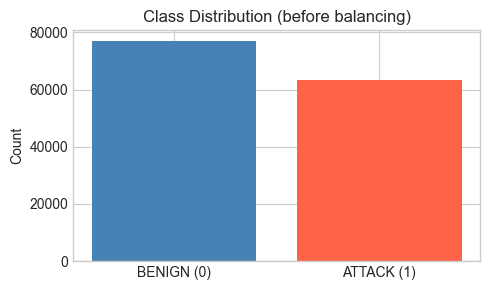

In [7]:
# Binary label encoding
df['label_bin'] = (df['Label'].str.upper() != 'BENIGN').astype(int)

X = df[feature_candidates].values.astype(np.float32)
y = df['label_bin'].values

cnt = Counter(y)
print('Class distribution:')
print(f'  BENIGN  (0): {cnt[0]:>10,}  ({cnt[0]/len(y)*100:.1f}%)')
print(f'  ATTACK  (1): {cnt[1]:>10,}  ({cnt[1]/len(y)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['BENIGN (0)', 'ATTACK (1)'], [cnt[0], cnt[1]], color=['steelblue', 'tomato'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution (before balancing)')
plt.tight_layout()
plt.show()

In [8]:
# 70/30 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

# MinMax normalisation (fit on train only to prevent leakage)
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Wrap as DataFrames for feature selection labelling
feat_names = np.array(feature_candidates)
X_train_df = pd.DataFrame(X_train_sc, columns=feat_names)
X_test_df  = pd.DataFrame(X_test_sc,  columns=feat_names)

print('Normalisation complete (MinMaxScaler fit on train set).')

Train: 98,299  |  Test: 42,129


Normalisation complete (MinMaxScaler fit on train set).


In [9]:
# Optional SMOTE balancing (training set only)
if APPLY_SMOTE:
    ratio = max(Counter(y_train).values()) / min(Counter(y_train).values())
    print(f'Class imbalance ratio (train): {ratio:.1f}:1')
    if ratio > 2:
        print('Applying SMOTE ...')
        sm = SMOTE(random_state=SEED)
        X_train_bal, y_train_bal = sm.fit_resample(X_train_df, y_train)
        X_train_df = pd.DataFrame(X_train_bal, columns=feat_names)
        y_train = y_train_bal
        print(f'After SMOTE — train: {X_train_df.shape[0]:,}')
        print('New class distribution:', Counter(y_train))
    else:
        print('Dataset is sufficiently balanced; SMOTE skipped.')
else:
    print('SMOTE skipped (APPLY_SMOTE=False).')

Class imbalance ratio (train): 1.2:1
Dataset is sufficiently balanced; SMOTE skipped.


## 3. FAMS Feature Selection

The FAMS **Feature Selection Algorithm** (Algorithm 1) runs 5 methods from 3 categories:

| Category | Method |
|---|---|
| Filter | **Variance** |
| Filter | **Mutual Information** |
| Wrapper | **Backward Elimination** (via RFE) |
| Embedded | **Lasso L1** |
| Embedded | **Random Forest Importance** |

Each method selects the top-25 features. A feature is retained if it appears in **> 3 methods** (i.e., ≥ 4 out of 5).

In [10]:
# ── Method 1: Filter — Variance ──────────────────────────────────────────────
# Remove zero-variance features first, then rank remaining by variance

print('Method 1: Variance Filter ...')

vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_df)
non_zero_var_feats = feat_names[vt.get_support()]

variances = X_train_df[non_zero_var_feats].var().sort_values(ascending=False)
selected_variance = variances.head(TOP_N_PER_METHOD).index.tolist()

print(f'  Non-zero variance features: {len(non_zero_var_feats)}')
print(f'  Top-{TOP_N_PER_METHOD} by variance: {len(selected_variance)} features')
print(f'  Sample: {selected_variance[:5]}')

Method 1: Variance Filter ...
  Non-zero variance features: 67
  Top-25 by variance: 25 features
  Sample: ['ACK Flag Count', 'PSH Flag Count', 'RST Flag Count', 'ECE Flag Count', 'Init Fwd Win Bytes']


Method 2: Mutual Information ...


  Top-25 by MI score: 25 features
  Sample: ['Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Init Bwd Win Bytes']


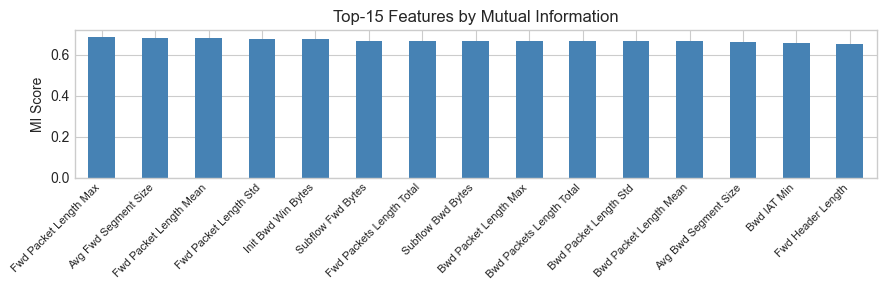

In [11]:
# ── Method 2: Filter — Mutual Information ───────────────────────────────────
# Measures dependency between each feature and the target label

print('Method 2: Mutual Information ...')

mi_scores = mutual_info_classif(
    X_train_df, y_train, discrete_features=False, random_state=SEED
)
mi_series = pd.Series(mi_scores, index=feat_names).sort_values(ascending=False)
selected_mi = mi_series.head(TOP_N_PER_METHOD).index.tolist()

print(f'  Top-{TOP_N_PER_METHOD} by MI score: {len(selected_mi)} features')
print(f'  Sample: {selected_mi[:5]}')

# Plot top-10 MI scores
fig, ax = plt.subplots(figsize=(9, 3))
mi_series.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top-15 Features by Mutual Information')
ax.set_xlabel('')
ax.set_ylabel('MI Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# ── Method 3: Wrapper — Backward Elimination (RFE) ──────────────────────────
# RFE recursively removes the least important feature until n_features_to_select remain
# Uses a fast DecisionTree estimator; may take 1-3 minutes on large datasets

print('Method 3: Backward Elimination (RFE) — this may take a few minutes ...')

# Subsample for RFE to speed up (RFE is O(n_features^2 * n_samples))
MAX_SAMPLES_RFE = 50_000
if len(X_train_df) > MAX_SAMPLES_RFE:
    idx = np.random.choice(len(X_train_df), MAX_SAMPLES_RFE, replace=False)
    X_rfe = X_train_df.iloc[idx]
    y_rfe = y_train[idx] if hasattr(y_train, '__getitem__') else np.array(y_train)[idx]
else:
    X_rfe, y_rfe = X_train_df, y_train

rfe_estimator = DecisionTreeClassifier(max_depth=5, random_state=SEED)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=TOP_N_PER_METHOD, step=3)
t0 = time.time()
rfe.fit(X_rfe, y_rfe)
print(f'  RFE completed in {time.time()-t0:.1f}s')

selected_rfe = feat_names[rfe.support_].tolist()
print(f'  Selected {len(selected_rfe)} features')
print(f'  Sample: {selected_rfe[:5]}')

Method 3: Backward Elimination (RFE) — this may take a few minutes ...


  RFE completed in 2.3s
  Selected 25 features
  Sample: ['Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max']


In [13]:
# ── Method 4: Embedded — Lasso L1 ───────────────────────────────────────────
# Logistic Regression with L1 penalty; features with non-zero coefficients are selected
# Rank by |coefficient| and take top-25

print('Method 4: Lasso L1 (Logistic Regression) ...')

MAX_SAMPLES_LASSO = 80_000
if len(X_train_df) > MAX_SAMPLES_LASSO:
    idx = np.random.choice(len(X_train_df), MAX_SAMPLES_LASSO, replace=False)
    X_lasso = X_train_df.iloc[idx]
    y_lasso = y_train[idx] if hasattr(y_train, '__getitem__') else np.array(y_train)[idx]
else:
    X_lasso, y_lasso = X_train_df, y_train

lasso_lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.1,
    max_iter=500, random_state=SEED
)
t0 = time.time()
lasso_lr.fit(X_lasso, y_lasso)
print(f'  Lasso LR fitted in {time.time()-t0:.1f}s')

coef_abs = np.abs(lasso_lr.coef_[0])
lasso_series = pd.Series(coef_abs, index=feat_names).sort_values(ascending=False)
# Keep features with non-zero coefficient, then top-25
non_zero = lasso_series[lasso_series > 0]
selected_lasso = non_zero.head(TOP_N_PER_METHOD).index.tolist()

print(f'  Non-zero coeff features: {len(non_zero)}')
print(f'  Selected top-{TOP_N_PER_METHOD}: {len(selected_lasso)} features')
print(f'  Sample: {selected_lasso[:5]}')

Method 4: Lasso L1 (Logistic Regression) ...


  Lasso LR fitted in 0.3s
  Non-zero coeff features: 17
  Selected top-25: 17 features
  Sample: ['Bwd Packet Length Std', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'ACK Flag Count', 'URG Flag Count']


In [14]:
# ── Method 5: Embedded — Random Forest Feature Importance ───────────────────

print('Method 5: Random Forest Feature Importance ...')

MAX_SAMPLES_RF_FS = 80_000
if len(X_train_df) > MAX_SAMPLES_RF_FS:
    idx = np.random.choice(len(X_train_df), MAX_SAMPLES_RF_FS, replace=False)
    X_rffs = X_train_df.iloc[idx]
    y_rffs = y_train[idx] if hasattr(y_train, '__getitem__') else np.array(y_train)[idx]
else:
    X_rffs, y_rffs = X_train_df, y_train

rf_fs = RandomForestClassifier(
    n_estimators=50, max_depth=10, max_samples=0.8,
    n_jobs=-1, random_state=SEED
)
t0 = time.time()
rf_fs.fit(X_rffs, y_rffs)
print(f'  RF fitted in {time.time()-t0:.1f}s')

importances = pd.Series(rf_fs.feature_importances_, index=feat_names).sort_values(ascending=False)
selected_rf_fs = importances.head(TOP_N_PER_METHOD).index.tolist()

print(f'  Selected top-{TOP_N_PER_METHOD}: {len(selected_rf_fs)} features')
print(f'  Sample: {selected_rf_fs[:5]}')

Method 5: Random Forest Feature Importance ...


  RF fitted in 0.2s
  Selected top-25: 25 features
  Sample: ['Fwd Packet Length Std', 'Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Bwd IAT Min', 'Subflow Fwd Bytes']


Vote threshold: > 3  (>= 4 of 5 methods)
FAMS selected 8 features:
               Feature  Votes                                                                     Methods
 Bwd Packet Length Std      5 Variance, Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
 Fwd Packet Length Std      5 Variance, Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
 Fwd Packet Length Max      5 Variance, Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
     Subflow Fwd Bytes      4           Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
     Fwd Header Length      4           Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
    Init Fwd Win Bytes      4                Variance, Mutual Information, Backward Elim. (RFE), Lasso L1
   Subflow Fwd Packets      4           Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
Fwd Packet Length Mean      4           Variance, Mutual Information, Backward Elim. 

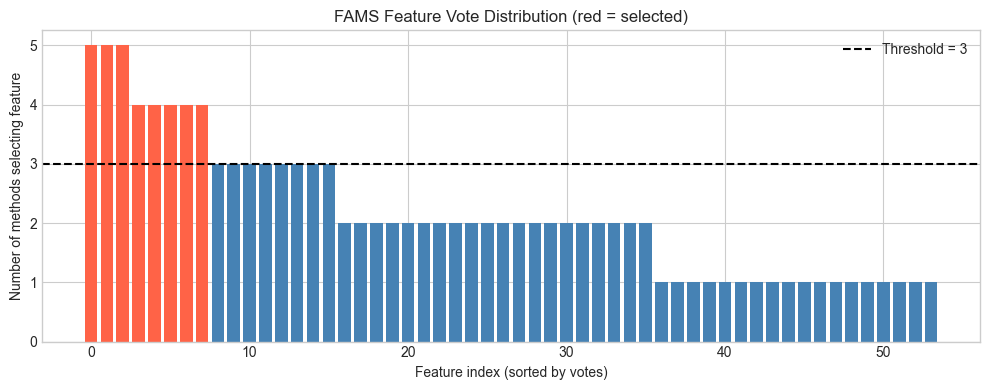

In [15]:
# ── FAMS Aggregation: vote count > VOTE_THRESHOLD ───────────────────────────

all_selected = [
    ('Variance',              selected_variance),
    ('Mutual Information',    selected_mi),
    ('Backward Elim. (RFE)',  selected_rfe),
    ('Lasso L1',              selected_lasso),
    ('RF Importance',         selected_rf_fs),
]

# Count votes per feature
vote_counter = Counter()
for method_name, feats in all_selected:
    vote_counter.update(feats)

vote_df = pd.DataFrame(
    [(f, v) for f, v in vote_counter.items()],
    columns=['Feature', 'Votes']
).sort_values('Votes', ascending=False)

# Add which methods selected each feature
method_map = {m: set(f) for m, f in all_selected}
vote_df['Methods'] = vote_df['Feature'].apply(
    lambda f: ', '.join([m for m, s in method_map.items() if f in s])
)

# FAMS rule: keep features with votes > VOTE_THRESHOLD
fams_features = vote_df[vote_df['Votes'] > VOTE_THRESHOLD]['Feature'].tolist()

print(f'Vote threshold: > {VOTE_THRESHOLD}  (>= {VOTE_THRESHOLD+1} of 5 methods)')
print(f'FAMS selected {len(fams_features)} features:')
print(vote_df[vote_df['Votes'] > VOTE_THRESHOLD][['Feature', 'Votes', 'Methods']].to_string(index=False))

# Visualise vote distribution
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tomato' if v > VOTE_THRESHOLD else 'steelblue' for v in vote_df['Votes']]
ax.bar(range(len(vote_df)), vote_df['Votes'], color=colors)
ax.axhline(y=VOTE_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold = {VOTE_THRESHOLD}')
ax.set_xlabel('Feature index (sorted by votes)')
ax.set_ylabel('Number of methods selecting feature')
ax.set_title('FAMS Feature Vote Distribution (red = selected)')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ── Compare FAMS output with paper's 21 features ────────────────────────────
# Feature names mapped to canonical column names used by both datasets after harmonisation.
# Paper names → canonical: e.g. "Max Packet Length" → "Packet Length Max",
# "Average Packet Size" → "Avg Packet Size", "Init_Win_bytes_*" → "Init *Win Bytes"

PAPER_21_FEATURES = [
    'Destination Port',       # IDS2018 only (from Dst Port); absent in DDoS2019
    'Fwd Packet Length Mean',
    'Flow IAT Max',
    'Subflow Bwd Bytes',
    'Init Bwd Win Bytes',     # paper: Init_Win_bytes_backward
    'Protocol',
    'Bwd Packets Length Total',  # paper: Total Length of Bwd Packets
    'Fwd Packet Length Max',
    'Fwd Packet Length Std',
    'Flow Bytes/s',
    'Fwd IAT Max',
    'Fwd Header Length',
    'Bwd Header Length',
    'Packet Length Max',      # paper: Max Packet Length
    'Packet Length Mean',
    'Packet Length Variance',
    'ACK Flag Count',
    'Avg Packet Size',        # paper: Average Packet Size
    'Avg Fwd Segment Size',
    'Init Fwd Win Bytes',     # paper: Init_Win_bytes_forward
    'Fwd Seg Size Min',       # paper: min_seg_size_forward
]

overlap = [f for f in PAPER_21_FEATURES if f in fams_features]
paper_available = [f for f in PAPER_21_FEATURES if f in feat_names]

print(f'Paper 21 features (canonical names): {len(PAPER_21_FEATURES)}')
print(f'Paper features in dataset:           {len(paper_available)}')
print(f'FAMS selected:                       {len(fams_features)}')
print(f'Overlap (FAMS ∩ Paper):              {len(overlap)}')

missing_from_data = [f for f in PAPER_21_FEATURES if f not in feat_names]
if missing_from_data:
    print(f'\nPaper features not in dataset: {missing_from_data}')

# Decide which features to use for model training
if len(fams_features) >= 5:
    FINAL_FEATURES = fams_features
    print(f'\nUsing FAMS-selected features ({len(FINAL_FEATURES)}).')
elif len(paper_available) >= 5:
    FINAL_FEATURES = paper_available
    print(f'\nFalling back to paper features available in dataset ({len(FINAL_FEATURES)}).')
else:
    FINAL_FEATURES = feat_names.tolist()[:21]
    print('\nFalling back to first 21 numeric features.')

print(f'Final feature set ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')


Paper 21 features (canonical names): 21
Paper features in dataset:           20
FAMS selected:                       8
Overlap (FAMS ∩ Paper):              5

Paper features not in dataset: ['Destination Port']

Using FAMS-selected features (8).
Final feature set (8): ['Bwd Packet Length Std', 'Fwd Packet Length Std', 'Fwd Packet Length Max', 'Subflow Fwd Bytes', 'Fwd Header Length', 'Init Fwd Win Bytes', 'Subflow Fwd Packets', 'Fwd Packet Length Mean']


In [17]:
# ── Finalise FAMS feature list ───────────────────────────────────────────────
# These features will be used to train/test models on CIC-DDoS 2019.
# (IDS2018 train/test arrays are no longer needed after feature selection.)

available_final = [f for f in FINAL_FEATURES if f in X_train_df.columns]
if len(available_final) < len(FINAL_FEATURES):
    missing_fs = [f for f in FINAL_FEATURES if f not in X_train_df.columns]
    print(f'[WARNING] {len(missing_fs)} features not in FS dataset: {missing_fs}')
    FINAL_FEATURES = available_final

print(f'FAMS final feature set ({len(FINAL_FEATURES)} features):')
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f'  {i:2d}. {f}')


FAMS final feature set (8 features):
   1. Bwd Packet Length Std
   2. Fwd Packet Length Std
   3. Fwd Packet Length Max
   4. Subflow Fwd Bytes
   5. Fwd Header Length
   6. Init Fwd Win Bytes
   7. Subflow Fwd Packets
   8. Fwd Packet Length Mean


## Phase 2: CIC-DDoS 2019 — Group-Based Generalisation Experiment

Attacks are divided into **3 groups by category**:

| Group | Attack Types |
|---|---|
| **G1 — UDP Amplification** | DNS, NTP, SNMP, UDP, UDPLag |
| **G2 — App Protocol** | LDAP, MSSQL, NetBIOS, Portmap, TFTP |
| **G3 — Flooding / Other** | Syn, WebDDoS |

**Experiment design** — 3 runs, each training on one group, testing on the unseen two:

| Experiment | Train on | Test on (unseen) |
|---|---|---|
| Exp 1 | G1 + Benign | G2 + G3 + Benign |
| Exp 2 | G2 + Benign | G1 + G3 + Benign |
| Exp 3 | G3 + Benign | G1 + G2 + Benign |

**Per experiment, per model:**
1. **Optuna** (30 trials, TPE, subsample) → best hyperparameters
2. **5-fold Stratified K-fold CV** with best params → CV F1 mean ± std
3. **Final training** on full training group → **evaluate on unseen test group**

In [18]:
# ── Attack type group definitions ────────────────────────────────────────────
ATTACK_GROUPS = {
    'G1_UDP_Amplification': ['DNS', 'NTP', 'SNMP', 'UDP', 'UDPLag'],
    'G2_App_Protocol':      ['LDAP', 'MSSQL', 'NetBIOS', 'Portmap', 'TFTP'],
    'G3_Flooding':          ['Syn', 'WebDDoS'],
}
# Reverse: label → group name
LABEL_TO_GROUP = {lbl: grp for grp, lbls in ATTACK_GROUPS.items() for lbl in lbls}
LABEL_TO_GROUP['Benign'] = 'Benign'

# ── Verify FINAL_FEATURES in DDoS 2019 ───────────────────────────────────────
ddos_features = [f for f in FINAL_FEATURES if f in df_ddos.columns]
missing_in_ddos = [f for f in FINAL_FEATURES if f not in df_ddos.columns]
if missing_in_ddos:
    print(f'[WARNING] Dropped (absent in DDoS2019): {missing_in_ddos}')
else:
    print(f'All {len(FINAL_FEATURES)} FAMS features present in DDoS 2019.')

# ── Preprocess DDoS 2019 ─────────────────────────────────────────────────────
df2 = df_ddos[ddos_features + ['Label']].copy()
for col in ddos_features:
    if df2[col].dtype == object:
        df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2.replace([np.inf, -np.inf], np.nan, inplace=True)
df2.dropna(inplace=True)
df2.drop_duplicates(inplace=True)

# Binary label + group assignment
df2['label_bin'] = (df2['Label'].str.upper() != 'BENIGN').astype(int)
df2['Group'] = df2['Label'].map(LABEL_TO_GROUP).fillna('Unknown')

print(f'DDoS2019 clean: {len(df2):,} rows')
print('\nSamples per group:')
grp_stats = df2.groupby('Group').agg(
    total=('label_bin', 'count'),
    attacks=('label_bin', 'sum'),
    benign=('label_bin', lambda x: (x == 0).sum())
).sort_values('total', ascending=False)
print(grp_stats.to_string())

print('\nLabel counts per group:')
for grp in ['G1_UDP_Amplification', 'G2_App_Protocol', 'G3_Flooding']:
    labels = df2[df2['Group'] == grp]['Label'].value_counts()
    print(f'\n  {grp}:')
    print(labels.to_string())

# ── Split Benign 70/30 — each experiment uses the SAME benign split ───────────
# This prevents Benign from appearing in both train and test simultaneously.
benign_df   = df2[df2['label_bin'] == 0].copy()
attack_df   = df2[df2['label_bin'] == 1].copy()
ben_train, ben_test = train_test_split(benign_df, test_size=0.30, random_state=SEED)
print(f'\nBenign split → train: {len(ben_train):,}  test: {len(ben_test):,}')

feat_names2 = np.array(ddos_features)


All 8 FAMS features present in DDoS 2019.
DDoS2019 clean: 45,708 rows

Samples per group:
                      total  attacks  benign
Group                                       
Benign                21172        0   21172
G1_UDP_Amplification  13477    13477       0
G2_App_Protocol       10868    10868       0
G3_Flooding             191      191       0

Label counts per group:

  G1_UDP_Amplification:
Label
NTP       7055
DNS       2110
UDP       2109
SNMP      1865
UDPLag     338

  G2_App_Protocol:
Label
MSSQL      7544
LDAP       1464
TFTP       1370
NetBIOS     343
Portmap     147

  G3_Flooding:
Label
Syn        169
WebDDoS     22

Benign split → train: 14,820  test: 6,352


## Experiment Engine: Optuna + K-fold CV per Group

In [19]:
# ── Model factory registry ────────────────────────────────────────────────────
MODEL_REGISTRY = {
    'KNN': {
        'param_space': lambda trial: {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
            'algorithm':   trial.suggest_categorical('algorithm', ['ball_tree', 'kd_tree', 'brute']),
            'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
        },
        'build': lambda p: KNeighborsClassifier(**p, n_jobs=-1),
        'train_cap': 50_000,   # KNN is O(n·d) at predict; cap training size
    },
    'RF': {
        'param_space': lambda trial: {
            'n_estimators':      trial.suggest_int('n_estimators', 50, 300),
            'max_depth':         trial.suggest_int('max_depth', 5, 30),
            'max_samples':       trial.suggest_float('max_samples', 0.5, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        },
        'build': lambda p: RandomForestClassifier(**p, n_jobs=-1, random_state=SEED),
        'train_cap': None,
    },
    'XGB': {
        'param_space': lambda trial: {
            'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        },
        'build': lambda p: XGBClassifier(
            **p, eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0),
        'train_cap': None,
    },
}

# Shared colour palette for all visualisation cells
colors = {'KNN': 'steelblue', 'RF': 'darkorange', 'XGB': 'forestgreen'}


def _optuna_subsample(X, y, n=OPTUNA_SUBSAMPLE):
    if len(X) <= n:
        return X, y
    idx = np.random.RandomState(SEED).choice(len(X), n, replace=False)
    return X[idx], np.asarray(y)[idx]


def evaluate_model(name, model, X_te, y_te, predict_time=None):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    avg  = (acc + prec + rec + f1) / 4
    auc  = roc_auc_score(y_te, y_proba) if y_proba is not None else None
    auc_s = f'{auc:.4f}' if auc is not None else 'N/A'
    print(f'    {name:<6}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_s}')
    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1_Score': f1, 'Average': avg,
        'AUC': auc, 'Predict_Time': predict_time,
        '_y_pred': y_pred, '_y_proba': y_proba,
    }


def _make_objective(cfg, X_tr, y_tr, X_val, y_val):
    """Factory to avoid closure-capture issues in loops."""
    def objective(trial):
        m = cfg['build'](cfg['param_space'](trial))
        m.fit(X_tr, y_tr)
        return f1_score(y_val, m.predict(X_val), zero_division=0)
    return objective


def run_group_experiment(exp_name, train_group, test_groups,
                         attack_df, ben_train, ben_test,
                         feature_cols, n_folds=5, n_trials=OPTUNA_TRIALS):
    """
    For one (train_group → test_groups) split:
    1. Build train/test datasets (disjoint Benign subsets)
    2. Scale (fit on train only)
    3. Optional SMOTE (train only)
    4. Per model: Optuna → K-fold CV → final train → test on unseen
    Returns dict {model_name: result}
    """
    print(f'\n{"="*65}')
    print(f'  {exp_name}')
    print(f'  Train: Benign({len(ben_train)}) + {train_group} attacks')
    print(f'  Test : Benign({len(ben_test)}) + {test_groups} attacks')
    print(f'{"="*65}')

    train_attacks = attack_df[attack_df['Group'] == train_group]
    test_attacks  = attack_df[attack_df['Group'].isin(test_groups)]

    if len(train_attacks) < 10:
        print(f'  [SKIP] Too few training attack samples ({len(train_attacks)})')
        return {}
    if len(test_attacks) < 10:
        print(f'  [SKIP] Too few test attack samples ({len(test_attacks)})')
        return {}

    train_df = pd.concat([ben_train, train_attacks], ignore_index=True)
    test_df  = pd.concat([ben_test,  test_attacks],  ignore_index=True)

    X_tr = train_df[feature_cols].values.astype(np.float32)
    y_tr = train_df['label_bin'].values
    X_te = test_df[feature_cols].values.astype(np.float32)
    y_te = test_df['label_bin'].values

    print(f'  Train samples: {len(X_tr):,}  class={Counter(y_tr)}')
    print(f'  Test  samples: {len(X_te):,}  class={Counter(y_te)}')

    # Scale
    sc = MinMaxScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    # SMOTE (train only)
    if APPLY_SMOTE:
        cnt = Counter(y_tr)
        ratio = max(cnt.values()) / max(min(cnt.values()), 1)
        if ratio > 2:
            sm = SMOTE(random_state=SEED)
            X_tr_sc, y_tr = sm.fit_resample(X_tr_sc, y_tr)
            print(f'  After SMOTE: {len(X_tr_sc):,} train  {Counter(y_tr)}')

    # Subsample for Optuna trials
    X_sub, y_sub = _optuna_subsample(X_tr_sc, y_tr)
    X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
        X_sub, y_sub, test_size=0.20, random_state=SEED, stratify=y_sub)

    # Subsample for K-fold CV (100k cap)
    X_cv, y_cv = _optuna_subsample(X_tr_sc, y_tr, n=min(len(X_tr_sc), 100_000))
    n_folds_eff = min(n_folds, int(np.min(np.bincount(y_cv))))
    cv_splitter = StratifiedKFold(n_splits=n_folds_eff, shuffle=True, random_state=SEED)

    exp_results = {}
    for model_name, cfg in MODEL_REGISTRY.items():
        print(f'  [{model_name}] Optuna({n_trials} trials) ...', end=' ', flush=True)
        t_start = time.time()

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=SEED)
        )
        study.optimize(
            _make_objective(cfg, X_tr_opt, y_tr_opt, X_val_opt, y_val_opt),
            n_trials=n_trials, show_progress_bar=False
        )
        print(f'best_F1_val={study.best_value:.4f} ({time.time()-t_start:.1f}s)', flush=True)

        # K-fold CV with best params
        cv_model = cfg['build'](study.best_params)
        cv_scores = cross_val_score(
            cv_model, X_cv, y_cv, cv=cv_splitter, scoring='f1', n_jobs=-1)
        print(f'    K-fold CV ({n_folds_eff}-fold): '
              f'F1={cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
              f'folds={np.round(cv_scores, 4)}')

        # Final model on full training set
        cap = cfg.get('train_cap')
        final_model = cfg['build'](study.best_params)
        if cap and len(X_tr_sc) > cap:
            idx_k = np.random.RandomState(SEED).choice(len(X_tr_sc), cap, replace=False)
            final_model.fit(X_tr_sc[idx_k], np.asarray(y_tr)[idx_k])
        else:
            final_model.fit(X_tr_sc, y_tr)

        t0 = time.time()
        result = evaluate_model(model_name, final_model, X_te_sc, y_te, time.time()-t0)
        result.update({
            'Best_Params': study.best_params,
            'CV_F1_mean':  round(float(cv_scores.mean()), 6),
            'CV_F1_std':   round(float(cv_scores.std()),  6),
            '_cv_scores':  cv_scores,
            '_study':      study,
            '_model':      final_model,
            '_scaler':     sc,
        })
        exp_results[model_name] = result

    return exp_results, y_te, X_te_sc


print('Experiment engine ready.')


Experiment engine ready.


In [20]:
# ── Run all 3 group experiments ───────────────────────────────────────────────

EXPERIMENTS = {
    'Exp1: Train G1 → Test G2+G3': ('G1_UDP_Amplification', ['G2_App_Protocol', 'G3_Flooding']),
    'Exp2: Train G2 → Test G1+G3': ('G2_App_Protocol',      ['G1_UDP_Amplification', 'G3_Flooding']),
    'Exp3: Train G3 → Test G1+G2': ('G3_Flooding',          ['G1_UDP_Amplification', 'G2_App_Protocol']),
}

all_experiments = {}

for exp_name, (train_grp, test_grps) in EXPERIMENTS.items():
    out = run_group_experiment(
        exp_name, train_grp, test_grps,
        attack_df, ben_train, ben_test,
        ddos_features
    )
    if not out:
        print(f'  Skipped: {exp_name}')
        continue
    exp_results, y_te_exp, X_te_exp = out
    all_experiments[exp_name] = {
        'train_group':  train_grp,
        'test_groups':  test_grps,
        'results':      exp_results,
        'y_test':       y_te_exp,
        'X_test_sc':    X_te_exp,
    }

print(f'\nCompleted {len(all_experiments)} experiments.')



  Exp1: Train G1 → Test G2+G3
  Train: Benign(14820) + G1_UDP_Amplification attacks
  Test : Benign(6352) + ['G2_App_Protocol', 'G3_Flooding'] attacks
  Train samples: 28,297  class=Counter({np.int64(0): 14820, np.int64(1): 13477})
  Test  samples: 17,411  class=Counter({np.int64(1): 11059, np.int64(0): 6352})


  [KNN] Optuna(30 trials) ... 

best_F1_val=0.9902 (2.1s)


    K-fold CV (5-fold): F1=0.9885 ± 0.0014  folds=[0.9875 0.9881 0.9871 0.9888 0.9911]


    KNN     Acc=0.9874  F1=0.9900  AUC=0.9930
  [RF] Optuna(30 trials) ... 

...

    K-fold CV (5-fold): F1=0.9889 ± 0.0020  folds=[0.9887 0.9894 0.9872 0.9923 0.9867]


    RF      Acc=0.5140  F1=0.5607  AUC=0.9814
  [XGB] Optuna(30 trials) ... 

best_F1_val=0.9867 (12.2s)


    K-fold CV (5-fold): F1=0.9868 ± 0.0020  folds=[0.9876 0.9869 0.985  0.9902 0.9845]


    XGB     Acc=0.6216  F1=0.6884  AUC=0.9792

Completed 3 experiments.


In [21]:
## Results



                 Experiment Model          Train_Group           CV_F1  Test_F1  Test_Acc  Test_Prec  Test_Rec  Test_AUC
Exp1: Train G1 → Test G2+G3   KNN G1_UDP_Amplification 0.9885 ± 0.0014   0.9900    0.9874     0.9968    0.9833    0.9930
Exp1: Train G1 → Test G2+G3    RF G1_UDP_Amplification 0.9906 ± 0.0016   0.9896    0.9870     0.9982    0.9813    0.9986
Exp1: Train G1 → Test G2+G3   XGB G1_UDP_Amplification 0.9904 ± 0.0015   0.9897    0.9871     0.9980    0.9816    0.9987
Exp2: Train G2 → Test G1+G3   KNN      G2_App_Protocol 0.9935 ± 0.0012   0.9824    0.9763     0.9979    0.9674    0.9867
Exp2: Train G2 → Test G1+G3    RF      G2_App_Protocol 0.9952 ± 0.0006   0.9842    0.9788     0.9989    0.9700    0.9981
Exp2: Train G2 → Test G1+G3   XGB      G2_App_Protocol 0.9945 ± 0.0008   0.9843    0.9788     0.9993    0.9696    0.9988
Exp3: Train G3 → Test G1+G2   KNN          G3_Flooding 0.9781 ± 0.0016   0.7827    0.7152     0.9911    0.6467    0.8472
Exp3: Train G3 → Test G1+G2    R

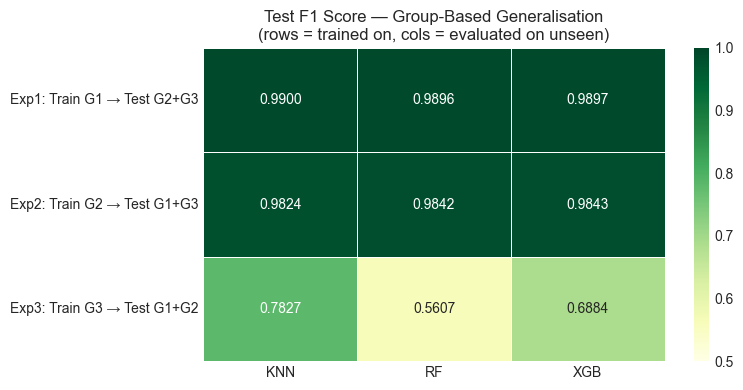

In [22]:
# ── Summary table: CV F1 vs Test F1 per experiment × model ───────────────────

rows = []
for exp_name, exp in all_experiments.items():
    for model_name, r in exp['results'].items():
        rows.append({
            'Experiment': exp_name,
            'Model':      model_name,
            'Train_Group':exp['train_group'],
            'CV_F1':      f"{r['CV_F1_mean']:.4f} ± {r['CV_F1_std']:.4f}",
            'Test_F1':    round(r['F1_Score'],   4),
            'Test_Acc':   round(r['Accuracy'],   4),
            'Test_Prec':  round(r['Precision'],  4),
            'Test_Rec':   round(r['Recall'],     4),
            'Test_AUC':   round(r['AUC'], 4) if r['AUC'] else None,
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# ── Heatmap: Test F1 per experiment × model ───────────────────────────────────
pivot = summary_df.pivot(index='Experiment', columns='Model', values='Test_F1')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Test F1 Score — Group-Based Generalisation\n(rows = trained on, cols = evaluated on unseen)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.show()


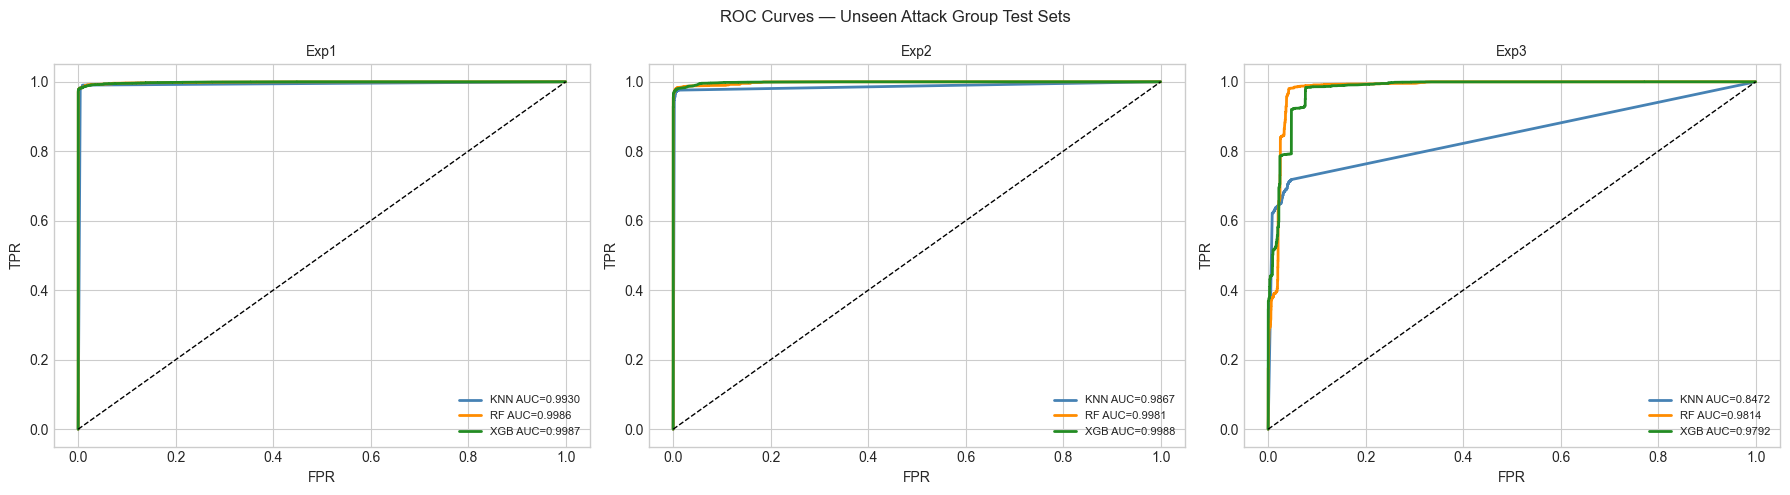

In [23]:
# ── ROC curves — one subplot per experiment ───────────────────────────────────

colors = {'KNN': 'steelblue', 'RF': 'darkorange', 'XGB': 'forestgreen'}
n_exp  = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(6 * n_exp, 5))
if n_exp == 1:
    axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    y_te = exp['y_test']
    for model_name, r in exp['results'].items():
        if r['_y_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_te, r['_y_proba'])
            ax.plot(fpr, tpr, color=colors[model_name], lw=2,
                    label=f"{model_name} AUC={r['AUC']:.4f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(exp_name.split(':')[0], fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves — Unseen Attack Group Test Sets', fontsize=12)
plt.tight_layout()
plt.show()


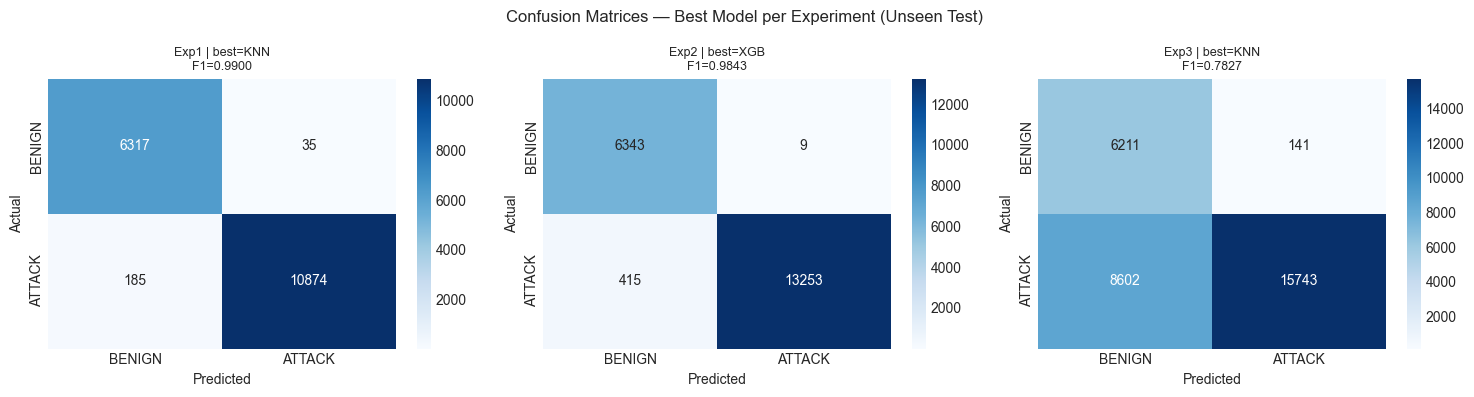

In [24]:
# ── Confusion matrices (best F1 model per experiment) ────────────────────────

n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4))
if n_exp == 1:
    axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    y_te = exp['y_test']
    # Pick model with highest test F1
    best_model = max(exp['results'], key=lambda m: exp['results'][m]['F1_Score'])
    r = exp['results'][best_model]
    cm = confusion_matrix(y_te, r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['BENIGN', 'ATTACK'], yticklabels=['BENIGN', 'ATTACK'])
    short = exp_name.split(':')[0]
    ax.set_title(f'{short} | best={best_model}\nF1={r["F1_Score"]:.4f}', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Best Model per Experiment (Unseen Test)', fontsize=12)
plt.tight_layout()
plt.show()


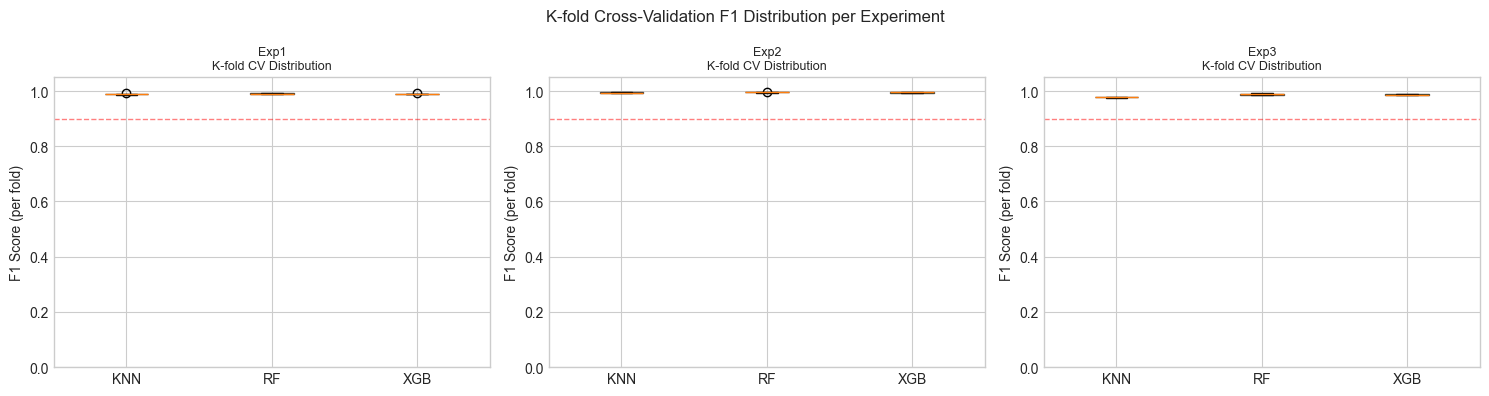


Exp1: Train G1 → Test G2+G3
  KNN     CV F1: 0.9885 ± 0.0014  folds=['0.9875', '0.9881', '0.9871', '0.9888', '0.9911']
  RF      CV F1: 0.9906 ± 0.0016  folds=['0.9886', '0.9914', '0.9893', '0.9907', '0.9931']
  XGB     CV F1: 0.9904 ± 0.0015  folds=['0.9892', '0.9903', '0.9888', '0.9907', '0.9931']

Exp2: Train G2 → Test G1+G3
  KNN     CV F1: 0.9935 ± 0.0012  folds=['0.9931', '0.9949', '0.9950', '0.9924', '0.9922']
  RF      CV F1: 0.9952 ± 0.0006  folds=['0.9954', '0.9952', '0.9963', '0.9945', '0.9949']
  XGB     CV F1: 0.9945 ± 0.0008  folds=['0.9940', '0.9949', '0.9956', '0.9933', '0.9947']

Exp3: Train G3 → Test G1+G2
  KNN     CV F1: 0.9781 ± 0.0016  folds=['0.9794', '0.9757', '0.9796', '0.9794', '0.9766']
  RF      CV F1: 0.9889 ± 0.0020  folds=['0.9887', '0.9894', '0.9872', '0.9923', '0.9867']
  XGB     CV F1: 0.9868 ± 0.0020  folds=['0.9876', '0.9869', '0.9850', '0.9902', '0.9845']


In [25]:
# ── K-fold CV F1 distribution per experiment ─────────────────────────────────

n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4))
if n_exp == 1:
    axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    model_names = list(exp['results'].keys())
    cv_data = [exp['results'][m]['_cv_scores'] for m in model_names]
    bp = ax.boxplot(cv_data, labels=model_names, patch_artist=True)
    for patch, clr in zip(bp['boxes'], [colors[m] for m in model_names]):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 Score (per fold)')
    ax.set_title(f'{exp_name.split(chr(58))[0]}\nK-fold CV Distribution', fontsize=9)
    ax.axhline(0.9, color='red', ls='--', lw=1, alpha=0.5)

plt.suptitle('K-fold Cross-Validation F1 Distribution per Experiment', fontsize=12)
plt.tight_layout()
plt.show()

# Print K-fold CV scores
for exp_name, exp in all_experiments.items():
    print(f'\n{exp_name}')
    for m, r in exp['results'].items():
        scores = r['_cv_scores']
        print(f'  {m:<6}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}  '
              f'folds={[f"{s:.4f}" for s in scores]}')


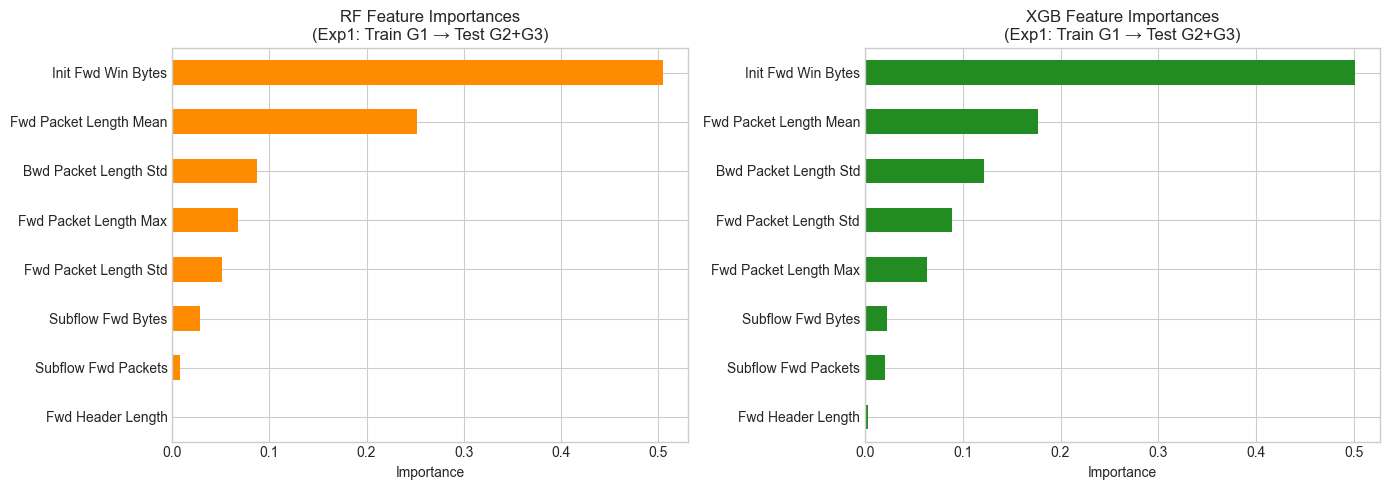

In [26]:
# ── Feature importance — RF and XGB (first experiment) ───────────────────────

first_exp = next(iter(all_experiments.values()))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mname, clr in zip(axes, ['RF', 'XGB'], ['darkorange', 'forestgreen']):
    if mname not in first_exp['results']:
        continue
    model = first_exp['results'][mname]['_model']
    imp = pd.Series(model.feature_importances_, index=ddos_features)
    imp.sort_values(ascending=False).plot(kind='barh', ax=ax, color=clr)
    ax.invert_yaxis()
    ax.set_title(f'{mname} Feature Importances\n({next(iter(all_experiments))})')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()


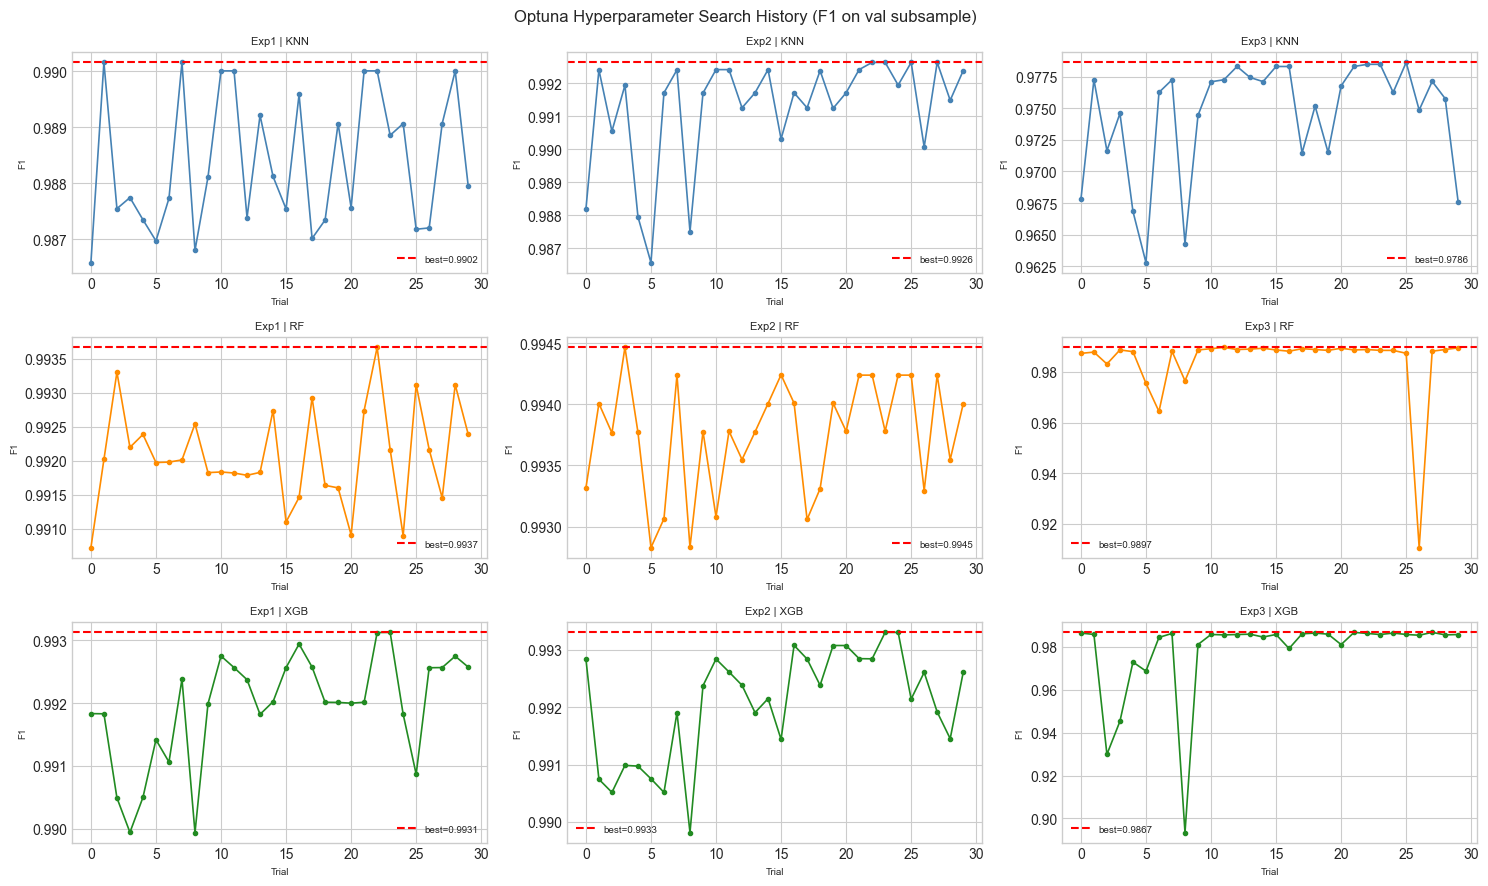

In [27]:
# ── Optuna optimisation history ───────────────────────────────────────────────

n_exp = len(all_experiments)
fig, axes = plt.subplots(len(MODEL_REGISTRY), n_exp,
                         figsize=(5 * n_exp, 3 * len(MODEL_REGISTRY)),
                         squeeze=False)

for col, (exp_name, exp) in enumerate(all_experiments.items()):
    for row, model_name in enumerate(MODEL_REGISTRY):
        ax = axes[row][col]
        if model_name not in exp['results']:
            ax.axis('off'); continue
        study = exp['results'][model_name]['_study']
        t_df  = study.trials_dataframe()
        ax.plot(t_df['number'], t_df['value'], 'o-',
                color=list(colors.values())[row], ms=3, lw=1.2)
        ax.axhline(study.best_value, color='red', ls='--', lw=1.5,
                   label=f'best={study.best_value:.4f}')
        ax.set_title(f'{exp_name.split(chr(58))[0]} | {model_name}', fontsize=8)
        ax.set_xlabel('Trial', fontsize=7); ax.set_ylabel('F1', fontsize=7)
        ax.legend(fontsize=7)

plt.suptitle('Optuna Hyperparameter Search History (F1 on val subsample)', fontsize=12)
plt.tight_layout()
plt.show()


In [28]:
# ── Detailed classification reports ──────────────────────────────────────────

for exp_name, exp in all_experiments.items():
    print(f'\n{"="*65}')
    print(f'  {exp_name}')
    print(f'  Tested on: {exp["test_groups"]}')
    print(f'{"="*65}')
    y_te = exp['y_test']
    for model_name, r in exp['results'].items():
        print(f'\n  -- {model_name} --')
        print(classification_report(
            y_te, r['_y_pred'], target_names=['BENIGN', 'ATTACK'], digits=4))



  Exp1: Train G1 → Test G2+G3
  Tested on: ['G2_App_Protocol', 'G3_Flooding']

  -- KNN --
              precision    recall  f1-score   support

      BENIGN     0.9715    0.9945    0.9829      6352
      ATTACK     0.9968    0.9833    0.9900     11059

    accuracy                         0.9874     17411
   macro avg     0.9842    0.9889    0.9864     17411
weighted avg     0.9876    0.9874    0.9874     17411


  -- RF --
              precision    recall  f1-score   support

      BENIGN     0.9683    0.9969    0.9824      6352
      ATTACK     0.9982    0.9813    0.9896     11059

    accuracy                         0.9870     17411
   macro avg     0.9833    0.9891    0.9860     17411
weighted avg     0.9873    0.9870    0.9870     17411


  -- XGB --
              precision    recall  f1-score   support

      BENIGN     0.9689    0.9965    0.9825      6352
      ATTACK     0.9980    0.9816    0.9897     11059

    accuracy                         0.9871     17411
   macro av

In [29]:
# ── Final summary: CV gap analysis (train vs unseen test) ─────────────────────

print('GENERALISATION SUMMARY')
print('='*80)
print(f'{"Experiment":<38} {"Model":<6} {"CV_F1":>12} {"Test_F1":>9} {"Gap":>8}')
print('-'*80)
for exp_name, exp in all_experiments.items():
    short = exp_name[:35]
    for model_name, r in exp['results'].items():
        gap  = r['CV_F1_mean'] - r['F1_Score']
        flag = '  ⚠ large gap' if abs(gap) > 0.1 else ''
        print(f'{short:<38} {model_name:<6} '
              f'{r["CV_F1_mean"]:.4f}±{r["CV_F1_std"]:.4f}  '
              f'{r["F1_Score"]:.4f}  {gap:+.4f}{flag}')

print('='*80)
print('\nNotes:')
print('  CV_F1   = 5-fold cross-validation on TRAINING group (same attack type as train)')
print('  Test_F1 = evaluation on UNSEEN attack groups (generalisation)')
print('  Gap     = CV_F1 - Test_F1  (positive = overfits to train attack type)')
print(f'\nFAMS features used: {ddos_features}')
print(f'Feature selection dataset: CIC-IDS 2018  |  Training/test dataset: CIC-DDoS 2019')


GENERALISATION SUMMARY
Experiment                             Model         CV_F1   Test_F1      Gap
--------------------------------------------------------------------------------
Exp1: Train G1 → Test G2+G3            KNN    0.9885±0.0014  0.9900  -0.0015
Exp1: Train G1 → Test G2+G3            RF     0.9906±0.0016  0.9896  +0.0010
Exp1: Train G1 → Test G2+G3            XGB    0.9904±0.0015  0.9897  +0.0007
Exp2: Train G2 → Test G1+G3            KNN    0.9935±0.0012  0.9824  +0.0111
Exp2: Train G2 → Test G1+G3            RF     0.9952±0.0006  0.9842  +0.0110
Exp2: Train G2 → Test G1+G3            XGB    0.9945±0.0008  0.9843  +0.0103
Exp3: Train G3 → Test G1+G2            KNN    0.9781±0.0016  0.7827  +0.1955  ⚠ large gap
Exp3: Train G3 → Test G1+G2            RF     0.9889±0.0020  0.5607  +0.4281  ⚠ large gap
Exp3: Train G3 → Test G1+G2            XGB    0.9868±0.0020  0.6884  +0.2984  ⚠ large gap

Notes:
  CV_F1   = 5-fold cross-validation on TRAINING group (same attack type as tra